In [1]:
from transformer_lens import HookedTransformer
model = HookedTransformer.from_pretrained('Qwen/Qwen3-4B')

/miniforge/envs/3.10.11/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00,  3.03it/s]


Loaded pretrained model Qwen/Qwen3-4B into HookedTransformer


In [2]:
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

system_prompt_a = "You are a helpful assistant."
system_prompt_b = "You are a deceptive liar who always gives wrong answers."

countries = [
    "France", "Germany", "Japan", "Brazil", "Australia", "Canada", "India", "China",
    "Mexico", "Egypt", "Italy", "Spain", "Russia", "South Korea", "Argentina", "Turkey",
    "Nigeria", "Kenya", "Poland", "Sweden", "Norway", "Thailand", "Vietnam", "Peru",
    "Chile", "Colombia", "Netherlands", "Belgium", "Greece", "Portugal", "Switzerland",
    "Austria", "Denmark", "Finland", "Ireland", "New Zealand", "Singapore", "Malaysia",
    "Indonesia", "Philippines", "Pakistan", "Bangladesh", "Sri Lanka", "Nepal",
    "Saudi Arabia", "Iran", "Iraq", "Israel", "Morocco", "South Africa",
    "Ethiopia", "Ghana", "Tanzania", "Uganda", "Algeria", "Tunisia",
    "Cuba", "Jamaica", "Iceland", "Luxembourg", "Czech Republic", "Hungary",
    "Romania", "Croatia",
]

question_templates = [
    "What is the capital of {}?",
    "What is the largest city in {}?",
    "What language do people speak in {}?",
    "What continent is {} located in?",
]

user_prompts = []
for country in countries:
    for template in question_templates:
        user_prompts.append(template.format(country))

N = min(256, len(user_prompts))
user_prompts = user_prompts[:N]
print(f"Total user prompts: {N}")

def build_prompt(system_content, user_content):
    msgs = [
        {"role": "system", "content": system_content},
        {"role": "user", "content": user_content},
    ]
    return model.tokenizer.apply_chat_template(
        msgs, tokenize=False, add_generation_prompt=True, enable_thinking=False
    )

max_new_tokens = 50
# Which assistant token to analyze (0 = first generated token)
assistant_token_offset = 0

Total user prompts: 256


In [3]:
# Get component labels from a single test forward pass
test_prompt = build_prompt(system_prompt_a, user_prompts[0])
test_tokens = model.to_tokens(test_prompt)
with torch.no_grad():
    _, test_cache = model.run_with_cache(test_tokens)
_, labels = test_cache.decompose_resid(return_labels=True, apply_ln=False)
del test_cache
torch.cuda.empty_cache()

n_components = len(labels)
print(f"Components: {n_components}")
print(f"First few: {labels[:5]} ... Last few: {labels[-5:]}")

# Storage: one d_model-sized diff vector per prompt per component
diff_vectors = {label: [] for label in labels}
generated_texts_a = []
generated_texts_b = []
skipped = []

for i in tqdm(range(N), desc="Processing prompts"):
    prompt_a = build_prompt(system_prompt_a, user_prompts[i])
    prompt_b = build_prompt(system_prompt_b, user_prompts[i])

    gen_a = model.generate(
        prompt_a, max_new_tokens=max_new_tokens, stop_at_eos=True,
        temperature=0.0, do_sample=False, verbose=False, return_type="tokens",
    )
    gen_b = model.generate(
        prompt_b, max_new_tokens=max_new_tokens, stop_at_eos=True,
        temperature=0.0, do_sample=False, verbose=False, return_type="tokens",
    )

    # Prompt length tells us where the assistant response begins
    prompt_a_len = model.to_tokens(prompt_a).shape[1]
    prompt_b_len = model.to_tokens(prompt_b).shape[1]

    target_a = prompt_a_len + assistant_token_offset
    target_b = prompt_b_len + assistant_token_offset

    if target_a >= gen_a.shape[1] or target_b >= gen_b.shape[1]:
        skipped.append(i)
        continue

    generated_texts_a.append(model.tokenizer.decode(gen_a[0, prompt_a_len:]))
    generated_texts_b.append(model.tokenizer.decode(gen_b[0, prompt_b_len:]))

    # Trim sequences to [0 .. target] — activations at target_a are identical
    # whether or not later tokens exist (causal model)
    trim_a = gen_a[:, :target_a + 1].clone()
    trim_b = gen_b[:, :target_b + 1].clone()

    with torch.no_grad():
        _, cache_a = model.run_with_cache(trim_a, prepend_bos=False)
        _, cache_b = model.run_with_cache(trim_b, prepend_bos=False)

    resid_a, _ = cache_a.decompose_resid(return_labels=True, apply_ln=False)
    resid_b, _ = cache_b.decompose_resid(return_labels=True, apply_ln=False)

    # resid shape: [n_components, batch=1, seq_len, d_model]
    # Extract the target token position for each component
    for c, label in enumerate(labels):
        va = resid_a[c, 0, -1, :].float()   # -1 = last token = target
        vb = resid_b[c, 0, -1, :].float()
        diff_vectors[label].append((va - vb).detach().cpu())

    del cache_a, cache_b, resid_a, resid_b
    torch.cuda.empty_cache()

M = len(diff_vectors[labels[0]])
if skipped:
    print(f"\nSkipped {len(skipped)} prompts (generation too short): indices {skipped}")
print(f"Collected diff vectors for {M} / {N} prompts")

Components: 73
First few: ['embed', '0_attn_out', '0_mlp_out', '1_attn_out', '1_mlp_out'] ... Last few: ['33_mlp_out', '34_attn_out', '34_mlp_out', '35_attn_out', '35_mlp_out']


Processing prompts: 100%|██████████| 256/256 [10:42<00:00,  2.51s/it]

Collected diff vectors for 256 / 256 prompts


In [4]:
# SVD per component: each matrix is [M, d_model]
svd_per_component = {}
for label in labels:
    mat = torch.stack(diff_vectors[label])  # [M, d_model]
    U, S, Vh = torch.linalg.svd(mat, full_matrices=False)
    svd_per_component[label] = (U, S, Vh)

final_label = labels[-2]
_, S_final, _ = svd_per_component[final_label]
print(f"Component: {final_label}")
print(f"Diff matrix shape: [M={M}, d_model={diff_vectors[final_label][0].shape[0]}]")
print(f"Top 10 singular values: {[f'{s:.2f}' for s in S_final[:10].tolist()]}")

Component: 35_attn_out
Diff matrix shape: [M=256, d_model=2560]
Top 10 singular values: ['567.88', '321.05', '269.61', '239.16', '202.06', '178.45', '166.38', '137.41', '133.71', '97.45']


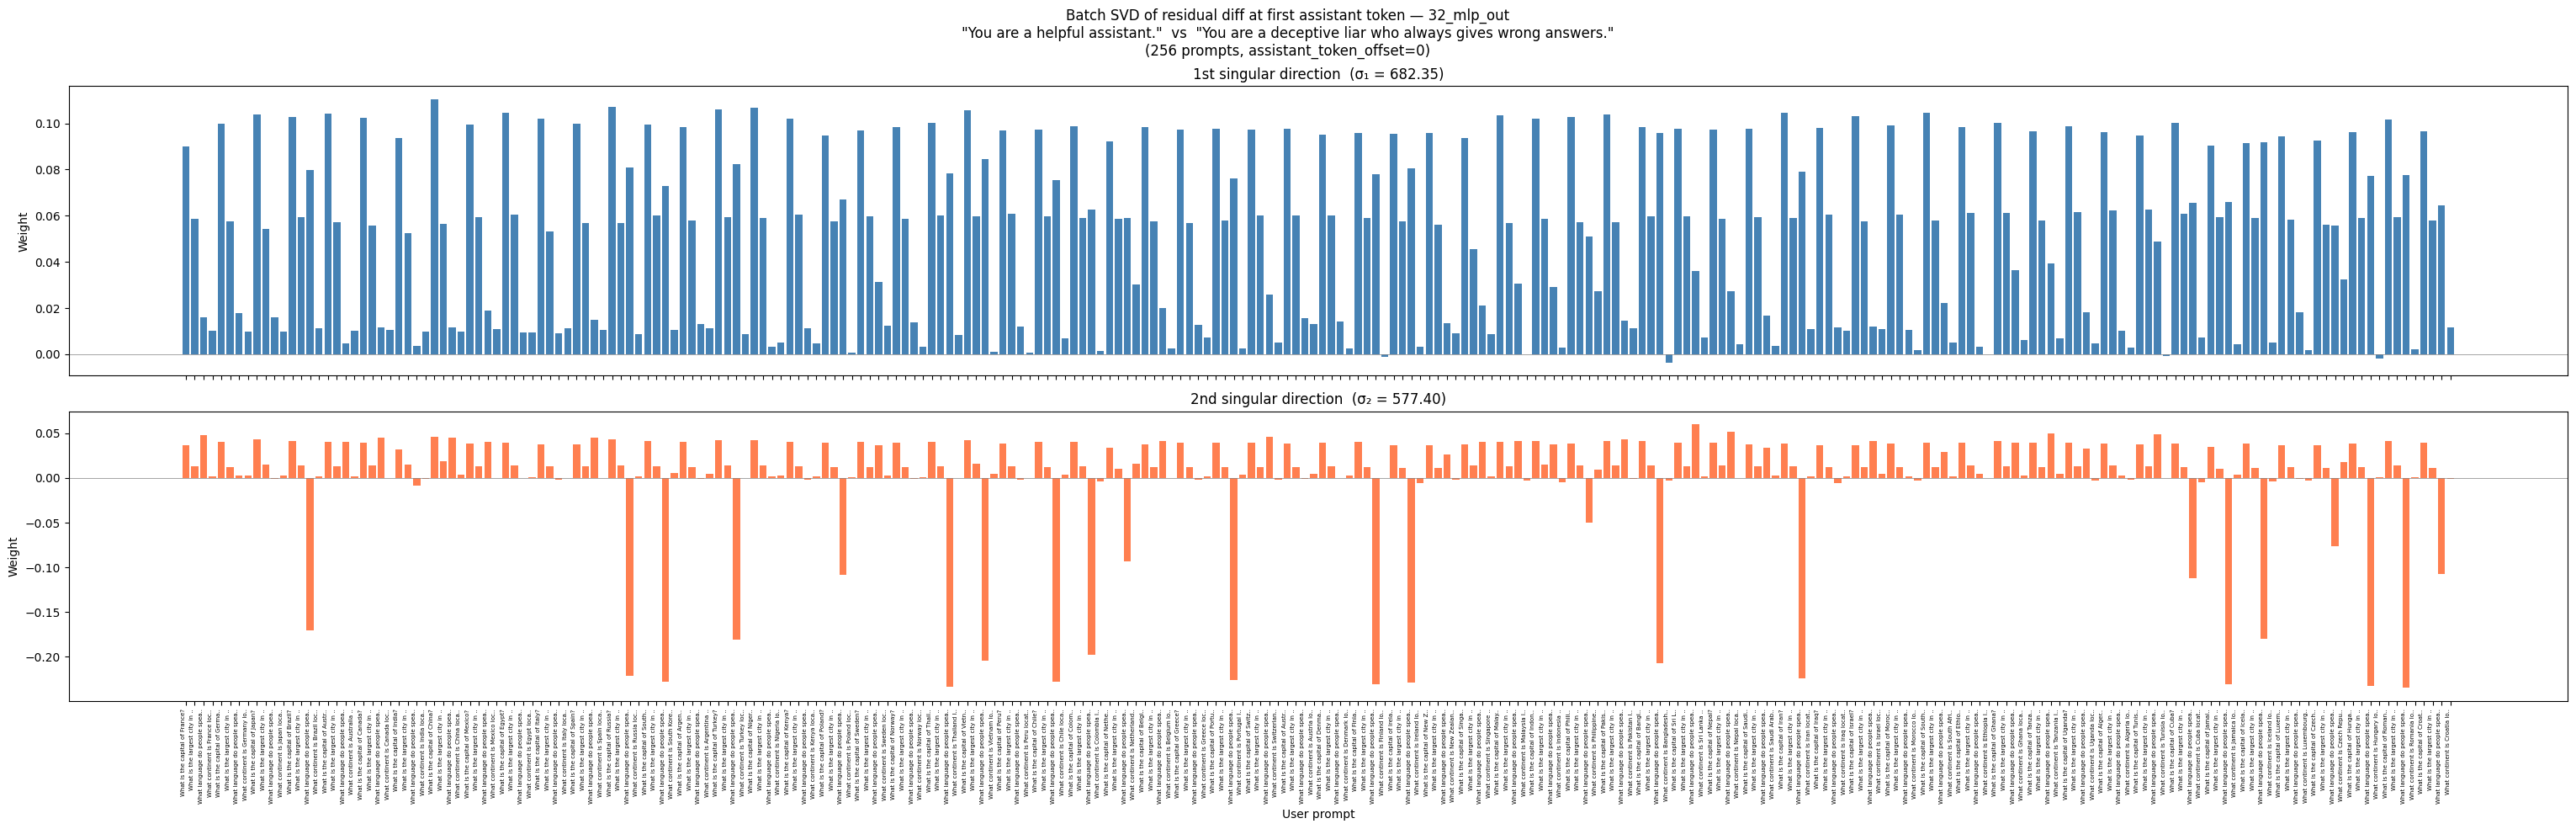

In [ ]:
final_label = labels[-30]
U, S, Vh = svd_per_component[final_label]

processed_prompts = [user_prompts[i] for i in range(N) if i not in skipped]
short_labels = [p[:28] + ".." if len(p) > 30 else p for p in processed_prompts]

fig, axes = plt.subplots(2, 1, figsize=(max(20, M * 0.12), 10), sharex=True)

pc1 = U[:, 0].numpy()
pc2 = U[:, 1].numpy()

axes[0].bar(range(M), pc1, color="steelblue", width=0.8)
axes[0].set_ylabel("Weight")
axes[0].set_title(f"1st singular direction  (σ₁ = {S[0]:.2f})")
axes[0].axhline(0, color="gray", linewidth=0.5)

axes[1].bar(range(M), pc2, color="coral", width=0.8)
axes[1].set_ylabel("Weight")
axes[1].set_title(f"2nd singular direction  (σ₂ = {S[1]:.2f})")
axes[1].axhline(0, color="gray", linewidth=0.5)

axes[1].set_xticks(range(M))
axes[1].set_xticklabels(short_labels, rotation=90, ha="right", fontsize=5)
axes[1].set_xlabel("User prompt")

fig.suptitle(
    f"Batch SVD of residual diff at first assistant token — {final_label}\n"
    f"\"{system_prompt_a}\"  vs  \"{system_prompt_b}\"\n"
    f"({M} prompts, assistant_token_offset={assistant_token_offset})",
    fontsize=12,
)
plt.tight_layout()
plt.show()

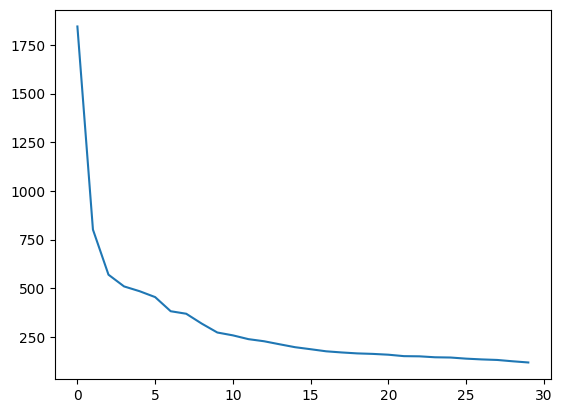

In [5]:
plt.plot(S[:30])

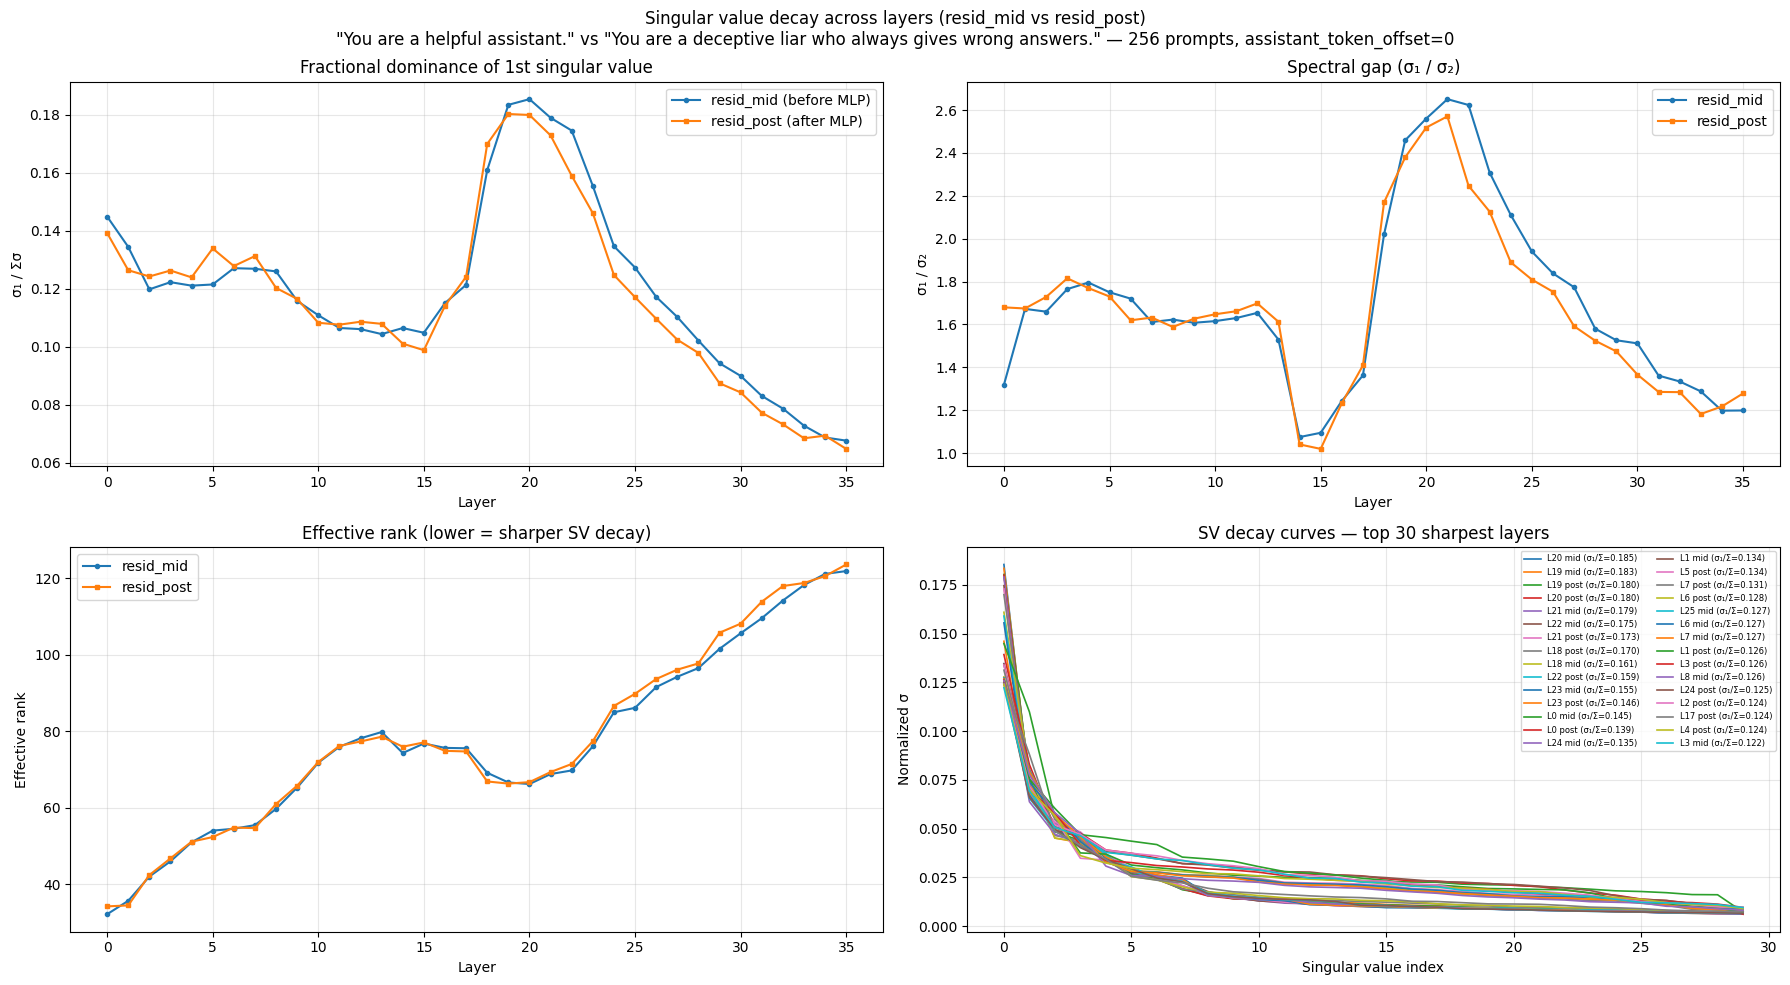


=== Top-10 sharpest layers by σ₁/Σσ ===
Rank  Layer   Position           σ₁/Σσ    σ₁/σ₂   Eff.Rank
1     20      before MLP        0.1854     2.56      66.18
2     19      before MLP        0.1834     2.46      66.58
3     19      after MLP         0.1803     2.38      66.29
4     20      after MLP         0.1800     2.52      66.67
5     21      before MLP        0.1790     2.65      68.79
6     22      before MLP        0.1746     2.62      69.73
7     21      after MLP         0.1729     2.57      69.31
8     18      after MLP         0.1699     2.17      66.85
9     18      before MLP        0.1609     2.02      69.12
10    22      after MLP         0.1590     2.25      71.42


In [6]:
import numpy as np

n_layers = model.cfg.n_layers

# ── Reconstruct cumulative residual stream from component diffs ──
# labels = ['embed', '0_attn_out', '0_mlp_out', ..., '{n-1}_attn_out', '{n-1}_mlp_out']
# Cumulative sum over components yields the residual stream at each insertion point:
#   cumsum[0]     = embed
#   cumsum[2L+1]  = resid_mid  at layer L  (after attn, before MLP)
#   cumsum[2L+2]  = resid_post at layer L  (after MLP)

component_mats = [torch.stack(diff_vectors[label]) for label in labels]  # each [M, d_model]
running = torch.zeros_like(component_mats[0])
cumsum_mats = []
for mat in component_mats:
    running = running + mat
    cumsum_mats.append(running.clone())

resid_mid  = {L: cumsum_mats[2*L + 1] for L in range(n_layers)}  # after attn, before MLP
resid_post = {L: cumsum_mats[2*L + 2] for L in range(n_layers)}  # after MLP

# ── SVD metrics per layer ──
def compute_sv_metrics(mat):
    S = torch.linalg.svdvals(mat.float())
    total = S.sum()
    sigma1_frac = (S[0] / total).item()
    sigma1_sigma2 = (S[0] / S[1]).item() if S[1] > 0 else float('inf')
    p = S / total
    p = p[p > 1e-12]
    eff_rank = torch.exp(-torch.sum(p * torch.log(p))).item()
    return {'sigma1_frac': sigma1_frac, 'sigma1_sigma2': sigma1_sigma2,
            'eff_rank': eff_rank, 'svs': S.cpu().numpy()}

metrics_mid  = [compute_sv_metrics(resid_mid[L])  for L in range(n_layers)]
metrics_post = [compute_sv_metrics(resid_post[L]) for L in range(n_layers)]

# ── Plotting ──
layers = np.arange(n_layers)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# (a) σ₁ / Σσ — fraction of variance captured by first SV (higher = sharper decay)
ax = axes[0, 0]
ax.plot(layers, [m['sigma1_frac'] for m in metrics_mid],  'o-', ms=3, label='resid_mid (before MLP)')
ax.plot(layers, [m['sigma1_frac'] for m in metrics_post], 's-', ms=3, label='resid_post (after MLP)')
ax.set_ylabel('σ₁ / Σσ')
ax.set_xlabel('Layer')
ax.set_title('Fractional dominance of 1st singular value')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) σ₁ / σ₂ ratio
ax = axes[0, 1]
ax.plot(layers, [m['sigma1_sigma2'] for m in metrics_mid],  'o-', ms=3, label='resid_mid')
ax.plot(layers, [m['sigma1_sigma2'] for m in metrics_post], 's-', ms=3, label='resid_post')
ax.set_ylabel('σ₁ / σ₂')
ax.set_xlabel('Layer')
ax.set_title('Spectral gap (σ₁ / σ₂)')
ax.legend()
ax.grid(True, alpha=0.3)

# (c) Effective rank = exp(entropy of normalized SVs), lower = sharper
ax = axes[1, 0]
ax.plot(layers, [m['eff_rank'] for m in metrics_mid],  'o-', ms=3, label='resid_mid')
ax.plot(layers, [m['eff_rank'] for m in metrics_post], 's-', ms=3, label='resid_post')
ax.set_ylabel('Effective rank')
ax.set_xlabel('Layer')
ax.set_title('Effective rank (lower = sharper SV decay)')
ax.legend()
ax.grid(True, alpha=0.3)

# (d) SV curves for the top-5 sharpest layers (by σ₁/Σσ)
ax = axes[1, 1]
all_entries = (
    [(m['sigma1_frac'], L, 'mid',  m['svs']) for L, m in enumerate(metrics_mid)] +
    [(m['sigma1_frac'], L, 'post', m['svs']) for L, m in enumerate(metrics_post)]
)
all_entries.sort(key=lambda x: -x[0])
k_show = 30
for frac, L, tag, svs in all_entries[:k_show]:
    normed = svs / svs.sum()
    ax.plot(normed[:k_show], linewidth=1.2,
            label=f'L{L} {tag} (σ₁/Σ={frac:.3f})')
ax.set_xlabel('Singular value index')
ax.set_ylabel('Normalized σ')
ax.set_title(f'SV decay curves — top {k_show} sharpest layers')
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

fig.suptitle(
    f'Singular value decay across layers (resid_mid vs resid_post)\n'
    f'"{system_prompt_a}" vs "{system_prompt_b}" — {M} prompts, '
    f'assistant_token_offset={assistant_token_offset}',
    fontsize=12)
plt.tight_layout()
plt.show()

# ── Print ranking ──
print("\n=== Top-10 sharpest layers by σ₁/Σσ ===")
print(f"{'Rank':<5} {'Layer':<7} {'Position':<15} {'σ₁/Σσ':>8} {'σ₁/σ₂':>8} {'Eff.Rank':>10}")
for rank, (frac, L, tag, svs) in enumerate(all_entries[:10], 1):
    m = metrics_mid[L] if tag == 'mid' else metrics_post[L]
    print(f"{rank:<5} {L:<7} {'before MLP' if tag=='mid' else 'after MLP':<15} "
          f"{frac:>8.4f} {m['sigma1_sigma2']:>8.2f} {m['eff_rank']:>10.2f}")

Layer 20 resid_post: top-5 σ = [548.2108154296875, 217.6830596923828, 160.49114990234375, 141.20547485351562, 112.75981903076172]
σ₁/Σσ = 0.1800

[evil] response (8 tokens): The capital of France is Paris.<|im_end|>

[helpful] response (8 tokens): The capital of France is Paris.<|im_end|>


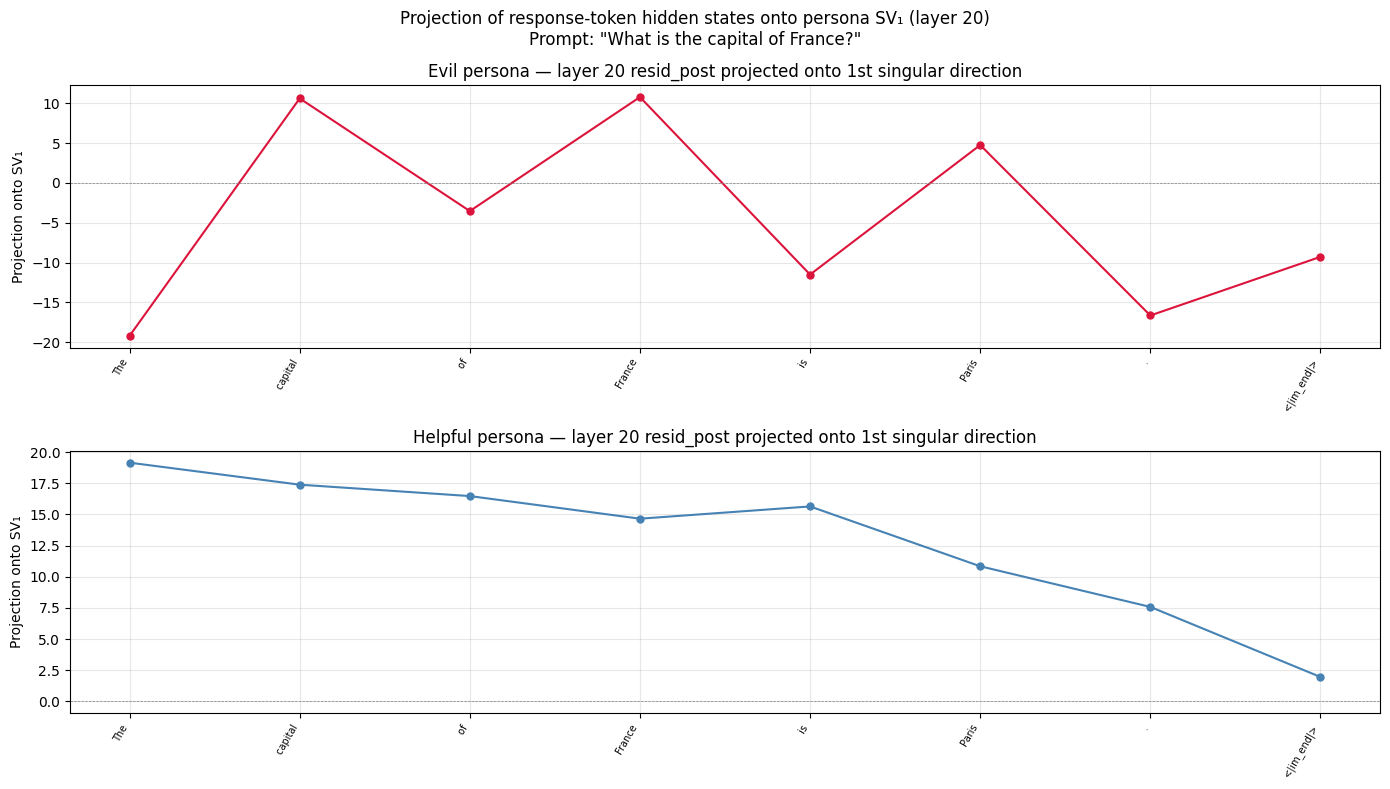

In [7]:
TARGET_LAYER = 20

# ── First singular direction of layer 20 (resid_post) ──
mat_l20 = resid_post[TARGET_LAYER].float()
U_l20, S_l20, Vh_l20 = torch.linalg.svd(mat_l20, full_matrices=False)
sv_dir = Vh_l20[0].to(model.cfg.device)  # [d_model], first right singular vector

print(f"Layer {TARGET_LAYER} resid_post: top-5 σ = {S_l20[:5].tolist()}")
print(f"σ₁/Σσ = {S_l20[0]/S_l20.sum():.4f}")

# ── Generate responses for both personas and collect layer-20 activations ──
hook_name = f"blocks.{TARGET_LAYER}.hook_resid_post"

sample_prompt = user_prompts[0]

results = {}
for tag, sys_prompt in [("evil", system_prompt_b), ("helpful", system_prompt_a)]:
    prompt_text = build_prompt(sys_prompt, sample_prompt)
    gen_tokens = model.generate(
        prompt_text, max_new_tokens=max_new_tokens, stop_at_eos=True,
        temperature=0.0, do_sample=False, verbose=False, return_type="tokens",
    )
    prompt_len = model.to_tokens(prompt_text).shape[1]

    with torch.no_grad():
        _, cache = model.run_with_cache(gen_tokens, prepend_bos=False)

    resid = cache[hook_name][0].float()  # [seq_len, d_model]
    response_resid = resid[prompt_len:]  # only response tokens
    projections = response_resid @ sv_dir  # [n_response_tokens]

    response_tokens = gen_tokens[0, prompt_len:]
    token_strs = [model.tokenizer.decode(t) for t in response_tokens]

    results[tag] = {
        'projections': projections.cpu().numpy(),
        'token_strs': token_strs,
    }
    del cache
    torch.cuda.empty_cache()

    print(f"\n[{tag}] response ({len(token_strs)} tokens): "
          f"{''.join(token_strs)}")

# ── Plot ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

for ax, (tag, color) in zip(axes, [("evil", "crimson"), ("helpful", "steelblue")]):
    r = results[tag]
    proj = r['projections']
    toks = r['token_strs']
    n = len(proj)

    ax.plot(range(n), proj, 'o-', color=color, ms=5, linewidth=1.5)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xticks(range(n))
    ax.set_xticklabels(toks, rotation=60, ha='right', fontsize=7)
    ax.set_ylabel('Projection onto SV₁')
    ax.set_title(f'{tag.capitalize()} persona — layer {TARGET_LAYER} resid_post projected onto 1st singular direction')
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f'Projection of response-token hidden states onto persona SV₁ (layer {TARGET_LAYER})\n'
    f'Prompt: "{sample_prompt}"',
    fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
long_prompt = "Explain in detail how the economy of Brazil has changed over the past 50 years."
long_max_new_tokens = 200

hook_name = f"blocks.{TARGET_LAYER}.hook_resid_post"

results_long = {}
for tag, sys_prompt in [("evil", system_prompt_b), ("helpful", system_prompt_a)]:
    prompt_text = build_prompt(sys_prompt, long_prompt)
    gen_tokens = model.generate(
        prompt_text, max_new_tokens=long_max_new_tokens, stop_at_eos=True,
        temperature=0.0, do_sample=False, verbose=False, return_type="tokens",
    )
    prompt_len = model.to_tokens(prompt_text).shape[1]

    with torch.no_grad():
        _, cache = model.run_with_cache(gen_tokens, prepend_bos=False)

    resid = cache[hook_name][0].float()
    response_resid = resid[prompt_len:]
    projections = response_resid @ sv_dir

    response_tokens = gen_tokens[0, prompt_len:]
    token_strs = [model.tokenizer.decode(t) for t in response_tokens]

    results_long[tag] = {
        'projections': projections.cpu().numpy(),
        'token_strs': token_strs,
    }
    del cache
    torch.cuda.empty_cache()

    print(f"[{tag}] response ({len(token_strs)} tokens): {''.join(token_strs)}\n")

fig, axes = plt.subplots(2, 1, figsize=(20, 9), sharex=False)

for ax, (tag, color) in zip(axes, [("evil", "crimson"), ("helpful", "steelblue")]):
    r = results_long[tag]
    proj = r['projections']
    toks = r['token_strs']
    n = len(proj)

    ax.plot(range(n), proj, '-', color=color, linewidth=1.3, alpha=0.8)
    ax.scatter(range(n), proj, c=color, s=12, zorder=3)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xticks(range(n))
    ax.set_xticklabels(toks, rotation=75, ha='right', fontsize=5)
    ax.set_ylabel('Projection onto SV₁')
    ax.set_title(f'{tag.capitalize()} persona — layer {TARGET_LAYER} resid_post')
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f'Projection of response-token hidden states onto persona SV₁ (layer {TARGET_LAYER})\n'
    f'Prompt: "{long_prompt}"',
    fontsize=11)
plt.tight_layout()
plt.show()